<a href="https://colab.research.google.com/github/chelymoon/masa-Invariante/blob/main/reconstruccion_de_masa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis de Datos Abiertos del CMS: Desintegración del Bosón Z a dos Muones

## 1. Lectura y exploración de los datos
En este análisis utilizaremos datos reales del detector CMS del Gran Colisionador de Hadrones (LHC). El conjunto de datos contiene eventos donde se detectaron exactamente dos muones.

Las variables disponibles por cada evento y su significado físico son:
* **Run :** Indica el periodo continuo de la toma de datos
* **Event:**  Número  especifico de la colisión dentro de este periodo.
* **pt1, pt2 (Momento Transversal - $P_T$):** Medido en gigaelectronvoltios (GeV). Es la cantidad de movimiento (momento) de la partícula proyectada en el plano transversal, es decir, perpendicular a la dirección del haz de protones que colisionaron. Es un indicador directo de la energía de la partícula.
* **eta1, eta2 (Pseudorrapidez - $\eta$):** Variable adimensional que describe el ángulo polar de la trayectoria respecto al haz. $\eta=0$ es perpendicular al haz.
* **phi1, phi2 (Ángulo azimutal - $\phi$):** Medido en radianes (de $-\pi$ a $\pi$). Es el ángulo en el plano transversal (el "corte transversal" del tubo del detector).
* **Q1, Q2 (Carga):** Carga eléctrica de la partícula en unidades de carga elemental (+1 o -1). Indica el signo de la carga eléctrica del muón. Como el bosón Z es una partícula neutra (carga 0), se espera que se desintegre en un par de muones con cargas opuestas (uno positivo y uno negativo).
* **dxy1, dxy2 (Parámetro de impacto transversal):** Medido en milímetros (mm). Es la distancia mínima desde la trayectoria reconstruida del muón hasta el punto de colisión primario (el punto exacto donde chocaron los protones). Valores muy cercanos a cero indican que el muón nació directamente en la colisión primaria (como ocurre con los que provienen del bosón Z).
* **iso1, iso2 (Aislamiento):** Medida (en GeV o adimensional según el criterio) de cuánta energía adicional hay depositada alrededor de la trayectoria del muón. Valores cercanos a 0 indican un muón "aislado", típico de la desintegración de un bosón pesado.



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual para las gráficas
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Carga de datos
url = 'https://opendata.cern.ch/record/5208/files/Zmumu.csv'
df = pd.read_csv(url)

# Mostramos las primeras filas y estadísticas básicas
display(df.head())
print(f"Total de eventos en la muestra: {len(df)}")

,Run,Event,pt1,eta1,phi1,Q1,dxy1,iso1,pt2,eta2,phi2,Q2,dxy2,iso2
0,165617,74969122,54.7055,-0.4324,2.5742,1,-0.0745,0.4999,34.2464,-0.9885,-0.4987,-1,0.0712,3.4221
1,165617,75138253,24.5872,-2.0522,2.8666,-1,-0.0554,0.0000,28.5389,0.3852,-1.9912,1,0.0515,0.0000
2,165617,75887636,31.7386,-2.2595,-1.3323,-1,0.0879,0.0000,30.2344,-0.4684,1.8833,1,-0.0876,0.0000
3,165617,75779415,39.7394,-0.7123,-0.3123,1,0.0585,0.0000,48.2790,-0.1956,2.9703,-1,-0.0492,0.0000
4,165617,75098104,41.2998,-0.1571,-3.0408,1,-0.0305,1.2280,43.4508,0.5910,-0.0428,-1,0.0442,0.0000


Total de eventos en la muestra: 10000


## 2. Análisis de las otras variables (Cinemática y Calidad)
A continuación, exploraremos las distribuciones de las propiedades individuales de los muones.

Observaremos tanto a los muones más energéticos (muón 1) como a los menos energéticos (muón 2).

* **Momento transversal ($p_T$):** Observamos un corte abrupto en 20 GeV. Esto no es una propiedad física, sino un filtro artificial aplicado a esta muestra de datos para eliminar ruido de fondo (partículas de baja energía).
* **Pseudorrapidez ($\eta$):** La distribución es simétrica respecto a 0 y se corta abruptamente en $\pm 2.1$. Esto se debe a la "aceptancia geométrica" del detector (dónde están ubicadas las cámaras de muones). La simetría indica que las partículas salen proyectadas por igual hacia ambos lados del detector.
* **Ángulo Azimutal ($\phi$):** Es una distribución plana entre $-\pi$ y $\pi$, lo cual refleja la simetría rotacional del haz de protones.
* **Carga (Q):** Al sumar las cargas ($Q_1 + Q_2$), el resultado es predominantemente 0. Esto confirma que los muones provienen de una partícula neutra (el Bosón Z).
* **Parámetro de impacto (dxy) y Aislamiento (iso):** Ambos tienen picos muy pronunciados en 0. Esto nos dice que los muones se originaron exactamente en el punto de colisión (son "prontos", no decaimientos de rayos cósmicos) y que están muy limpios de otras partículas (aislados).

<>:14: SyntaxWarning: invalid escape sequence '\e'
<>:15: SyntaxWarning: invalid escape sequence '\e'
<>:21: SyntaxWarning: invalid escape sequence '\p'
<>:22: SyntaxWarning: invalid escape sequence '\p'
<>:14: SyntaxWarning: invalid escape sequence '\e'
<>:15: SyntaxWarning: invalid escape sequence '\e'
<>:21: SyntaxWarning: invalid escape sequence '\p'
<>:22: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_2064/50757066.py:14: SyntaxWarning: invalid escape sequence '\e'
  axs[0, 1].set_title('Pseudorrapidez ($\eta$)')
/tmp/ipykernel_2064/50757066.py:15: SyntaxWarning: invalid escape sequence '\e'
  axs[0, 1].set_xlabel('$\eta$')
/tmp/ipykernel_2064/50757066.py:21: SyntaxWarning: invalid escape sequence '\p'
  axs[0, 2].set_title('Ángulo Azimutal ($\phi$)')
/tmp/ipykernel_2064/50757066.py:22: SyntaxWarning: invalid escape sequence '\p'
  axs[0, 2].set_xlabel('$\phi$ [rad]')


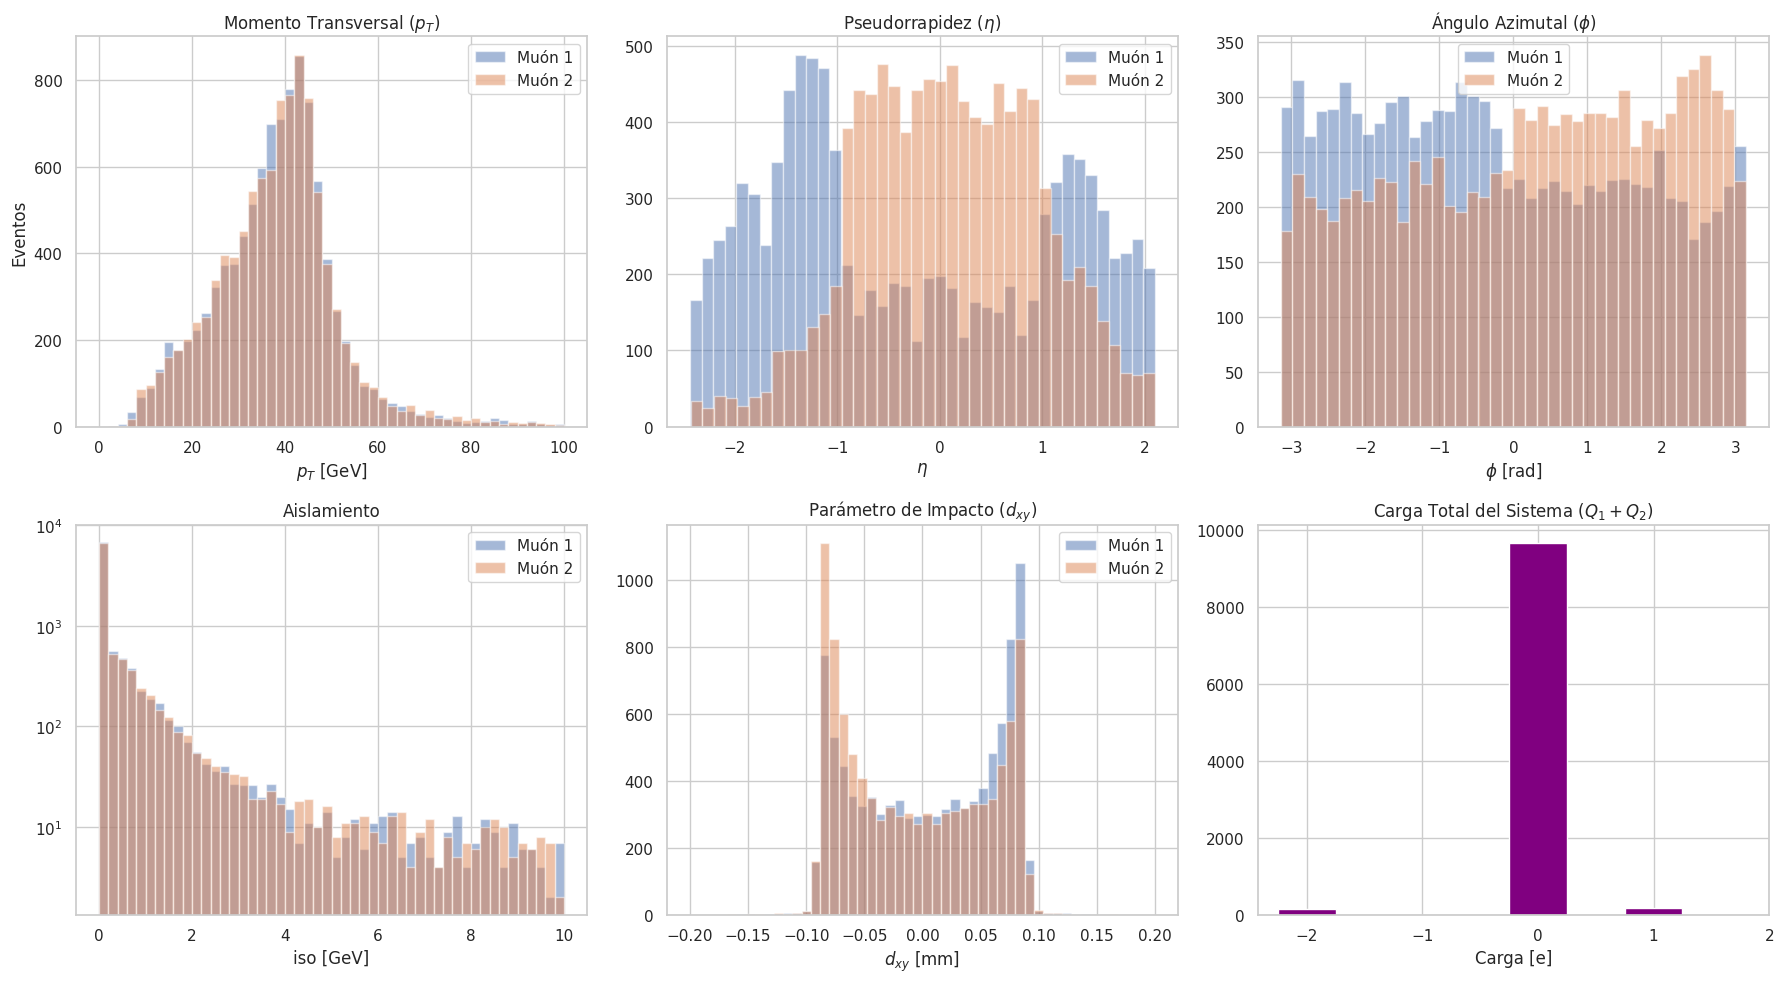

In [ ]:
fig, axs = plt.subplots(2, 3, figsize=(18, 10))

# Distribución de pT
axs[0, 0].hist(df['pt1'], bins=50, alpha=0.5, label='Muón 1', range=(0,100))
axs[0, 0].hist(df['pt2'], bins=50, alpha=0.5, label='Muón 2', range=(0,100))
axs[0, 0].set_title('Momento Transversal ($p_T$)')
axs[0, 0].set_xlabel('$p_T$ [GeV]')
axs[0, 0].set_ylabel('Eventos')
axs[0, 0].legend()

# Distribución de eta
axs[0, 1].hist(df['eta1'], bins=40, alpha=0.5, label='Muón 1')
axs[0, 1].hist(df['eta2'], bins=40, alpha=0.5, label='Muón 2')
axs[0, 1].set_title('Pseudorrapidez ($\eta$)')
axs[0, 1].set_xlabel('$\eta$')
axs[0, 1].legend()

# Distribución de phi
axs[0, 2].hist(df['phi1'], bins=40, alpha=0.5, label='Muón 1')
axs[0, 2].hist(df['phi2'], bins=40, alpha=0.5, label='Muón 2')
axs[0, 2].set_title('Ángulo Azimutal ($\phi$)')
axs[0, 2].set_xlabel('$\phi$ [rad]')
axs[0, 2].legend()

# Aislamiento (iso)
axs[1, 0].hist(df['iso1'], bins=50, alpha=0.5, label='Muón 1', range=(0, 10))
axs[1, 0].hist(df['iso2'], bins=50, alpha=0.5, label='Muón 2', range=(0, 10))
axs[1, 0].set_title('Aislamiento')
axs[1, 0].set_xlabel('iso [GeV]')
axs[1, 0].set_yscale('log') # Escala logarítmica para ver la cola
axs[1, 0].legend()

# Parámetro de impacto (dxy)
axs[1, 1].hist(df['dxy1'], bins=50, alpha=0.5, label='Muón 1', range=(-0.2, 0.2))
axs[1, 1].hist(df['dxy2'], bins=50, alpha=0.5, label='Muón 2', range=(-0.2, 0.2))
axs[1, 1].set_title('Parámetro de Impacto ($d_{xy}$)')
axs[1, 1].set_xlabel('$d_{xy}$ [mm]')
axs[1, 1].legend()

# Carga Total
carga_total = df['Q1'] + df['Q2']
axs[1, 2].hist(carga_total, bins=[-2, -1, 0, 1, 2], align='left', rwidth=0.5, color='purple')
axs[1, 2].set_title('Carga Total del Sistema ($Q_1 + Q_2$)')
axs[1, 2].set_xlabel('Carga [e]')
axs[1, 2].set_xticks([-2, -1, 0, 1, 2])

plt.tight_layout()
plt.show()

## 3. Correlaciones Interesantes
Una correlación muy importante al estudiar el decaimiento de una partícula masiva es la diferencia del ángulo azimutal ($\Delta\phi = \phi_1 - \phi_2$) entre los dos muones resultantes.

Dado que el bosón Z se produce en reposo (o casi en reposo) en el plano transversal, por la **conservación del momento**, los dos muones deben salir disparados en direcciones opuestas en ese plano. Por lo tanto, esperamos que la diferencia entre sus ángulos sea aproximadamente $\pi$ (180 grados). Esta topología se llama "Back-to-Back" (espalda con espalda).

<>:8: SyntaxWarning: invalid escape sequence '\D'
<>:9: SyntaxWarning: invalid escape sequence '\D'
<>:11: SyntaxWarning: invalid escape sequence '\p'
<>:8: SyntaxWarning: invalid escape sequence '\D'
<>:9: SyntaxWarning: invalid escape sequence '\D'
<>:11: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_2064/1233939967.py:8: SyntaxWarning: invalid escape sequence '\D'
  plt.title('Diferencia angular en el plano transversal ($\Delta\phi$)')
/tmp/ipykernel_2064/1233939967.py:9: SyntaxWarning: invalid escape sequence '\D'
  plt.xlabel('$\Delta\phi$ [rad]')
/tmp/ipykernel_2064/1233939967.py:11: SyntaxWarning: invalid escape sequence '\p'
  plt.axvline(np.pi, color='red', linestyle='--', label='$\pi$ (Espalda con espalda)')


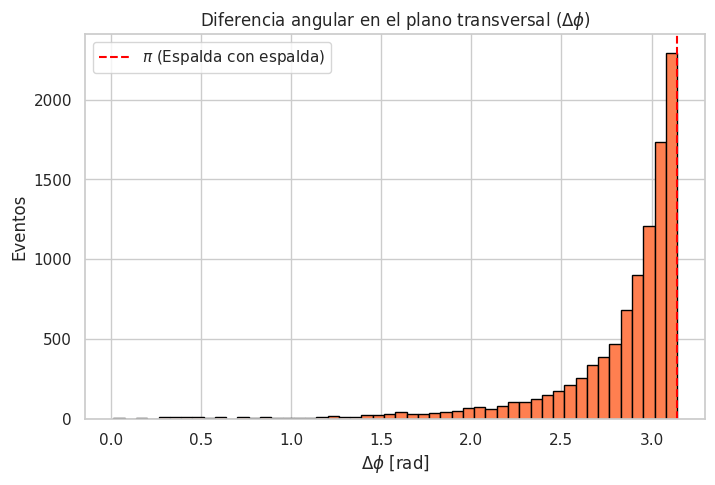

In [ ]:
# Cálculo de delta phi
delta_phi = np.abs(df['phi1'] - df['phi2'])
# Asegurarnos de que el ángulo esté entre 0 y pi
delta_phi = np.where(delta_phi > np.pi, 2*np.pi - delta_phi, delta_phi)

plt.figure(figsize=(8, 5))
plt.hist(delta_phi, bins=50, color='coral', edgecolor='black')
plt.title('Diferencia angular en el plano transversal ($\Delta\phi$)')
plt.xlabel('$\Delta\phi$ [rad]')
plt.ylabel('Eventos')
plt.axvline(np.pi, color='red', linestyle='--', label='$\pi$ (Espalda con espalda)')
plt.legend()
plt.show()

##2. Cálculo y Distribución de la Masa Invariante

Utilizamos el principio de conservación de la energía y el momento de la relatividad especial. La ecuación exacta de la masa invariante al cuadrado es $M^2 = (E_1 + E_2)^2 - (\vec{p}_1 + \vec{p}_2)^2$.

**Aproximación realizada:**
Sustituyendo las variables cinemáticas ($p_T, \eta, \phi$) y haciendo la aproximación de que la masa del muón en reposo ($m_\mu \approx 0.105$ GeV) es minúscula comparada con su momento (que es mayor a 20 GeV), asumimos que $E \approx |\vec{p}|$. Esto nos lleva a la fórmula simplificada:

$$M = \sqrt{2 p_{t1} p_{t2} (\cosh(\eta_1 - \eta_2) - \cos(\phi_1 - \phi_2))}$$

Al graficar esta masa, observamos una estructura tipo "pico" o resonancia.
* **¿Dónde se encuentra el máximo?** Alrededor de los 91 GeV.
* **¿Con qué partícula es compatible?** Con el **Bosón Z**, cuya masa teórica en el Modelo Estándar es de $\sim 91.18$ GeV.
* **¿Por qué tiene un ancho?** La distribución no es una sola línea vertical debido a dos motivos:
  1. *Física cuántica:* El bosón Z tiene una vida media muy corta, lo que por el Principio de Incertidumbre de Heisenberg se traduce en una "anchura natural" ($\Gamma \approx 2.5$ GeV).
  2. *Resolución experimental:* Los detectores no son perfectos; hay una pequeña incertidumbre al medir los momentos de los muones.

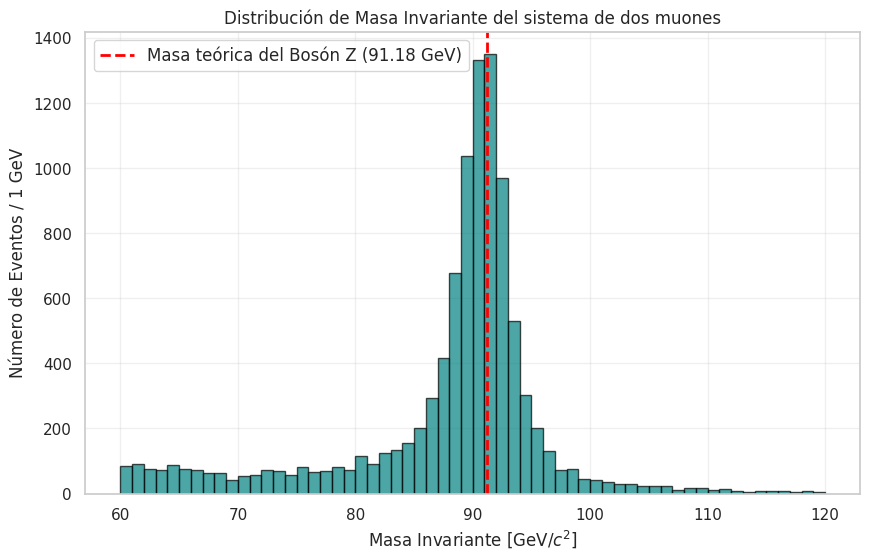

In [ ]:
# Cálculo de la masa invariante usando la aproximación relativista
M2 = 2 * df['pt1'] * df['pt2'] * (np.cosh(df['eta1'] - df['eta2']) - np.cos(df['phi1'] - df['phi2']))
df['Masa_Invariante'] = np.sqrt(M2)

# Histograma de la Masa Invariante
plt.figure(figsize=(10, 6))
plt.hist(df['Masa_Invariante'], bins=60, range=(60, 120), color='teal', edgecolor='black', alpha=0.7)
plt.title('Distribución de Masa Invariante del sistema de dos muones')
plt.xlabel('Masa Invariante [GeV/$c^2$]', fontsize=12)
plt.ylabel('Número de Eventos / 1 GeV', fontsize=12)

# Línea vertical indicando la masa teórica del Bosón Z
plt.axvline(91.18, color='red', linestyle='dashed', linewidth=2, label='Masa teórica del Bosón Z (91.18 GeV)')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()



## 5. Interpretación y Conclusiones sobre los Cortes de Selección (Cuts)

Al observar todas estas distribuciones, es fundamental recordar que esta muestra **no representa todos los eventos que ocurren en el LHC**, sino una porción filtrada.

1. **Corte de $p_T > 20$ GeV:** Se aplica para enfocarse en física de altas energías. Partículas con menor energía suelen ser producto de ruido de fondo ("background") o decaimientos de partículas ligeras. Si miramos el histograma de $p_T$, la caída vertical al lado izquierdo en 20 GeV es una consecuencia directa de este corte impuesto por los físicos, no una ley natural de los muones.
2. **Corte de $|\eta| < 2.1$:** Responde estrictamente a las limitaciones físicas y geométricas del detector CMS. Los muones que escapan a un ángulo mayor a 2.1 salen tan paralelos al haz que no cruzan suficientes capas de las cámaras de muones para ser reconstruidos con precisión.
3. **Masa del par entre 60 y 120 GeV:** Se elige esta "ventana" específica para rodear el pico del bosón Z (91 GeV). Si extendiéramos la gráfica hacia masas más bajas (ej. 2-10 GeV) veríamos una enorme cantidad de eventos provenientes del proceso Drell-Yan o de resonancias más ligeras (como $J/\psi$ o $\Upsilon$). Este corte limpia drásticamente nuestro análisis para centrarnos exclusivamente en la desintegración del Bosón Z.



In [ ]:
import pandas as pd
import numpy as np
import plotly.express as px

particles = pd.read_csv('https://opendata.cern.ch/record/5208/files/Zmumu.csv', delimiter=',')

p1 = particles['pt1']
p2 = particles['pt2']
eta1 = particles['eta1']
eta2 = particles['eta2']
phi1 = particles['phi1']
phi2 = particles['phi2']

M2 = 2 * p1 * p2 * (np.cosh(eta1 - eta2) - np.cos(phi1 - phi2))

M = np.sqrt(M2)

particles['invariant_mass'] = M

print(particles[['pt1', 'pt2', 'eta1', 'eta2', 'phi1', 'phi2', 'invariant_mass']].head())

fig = px.histogram(particles, x='invariant_mass', nbins=100,
                   title='Masa invariante del sistema ',
                   labels={'invariant_mass': 'Masa invariante [GeV]'})
fig.show()

       pt1      pt2    eta1    eta2    phi1    phi2  invariant_mass
0  54.7055  34.2464 -0.4324 -0.9885  2.5742 -0.4987       89.885919
1  24.5872  28.5389 -2.0522  0.3852  2.8666 -1.9912       88.812177
2  31.7386  30.2344 -2.2595 -0.4684 -1.3323  1.8833       88.474683
3  39.7394  48.2790 -0.7123 -0.1956 -0.3123  2.9703       90.332429
4  41.2998  43.4508 -0.1571  0.5910 -3.0408 -0.0428       90.515882


In [ ]:
fig = px.scatter(particles, x='dxy1', y='iso1',
                 title='iso vs dxy para el primer muón',
                 labels={'dxy1': 'dxy [mm]', 'iso1': 'Aislamiento'},
                 color='Q1',
                 opacity=0.5)
fig.show()


AJUSTE GAUSSIANO
Media: 90.740 ± 0.098 GeV
Sigma (resolución): 2.279 ± 0.088 GeV
Amplitud: 712.4 ± 37.5
Fondo: 29.3 ± 3.2
FWHM: 5.368 GeV

AJUSTE BREIT-WIGNER RELATIVISTA
Masa: 90.667 ± 0.082 GeV
Anchura (Γ): 3.957 ± 0.228 GeV
Amplitud: 885.9 ± 45.3
Fondo: -0.7 ± 4.0
Vida media (τ = ħ/Γ): 1.66e-25 s


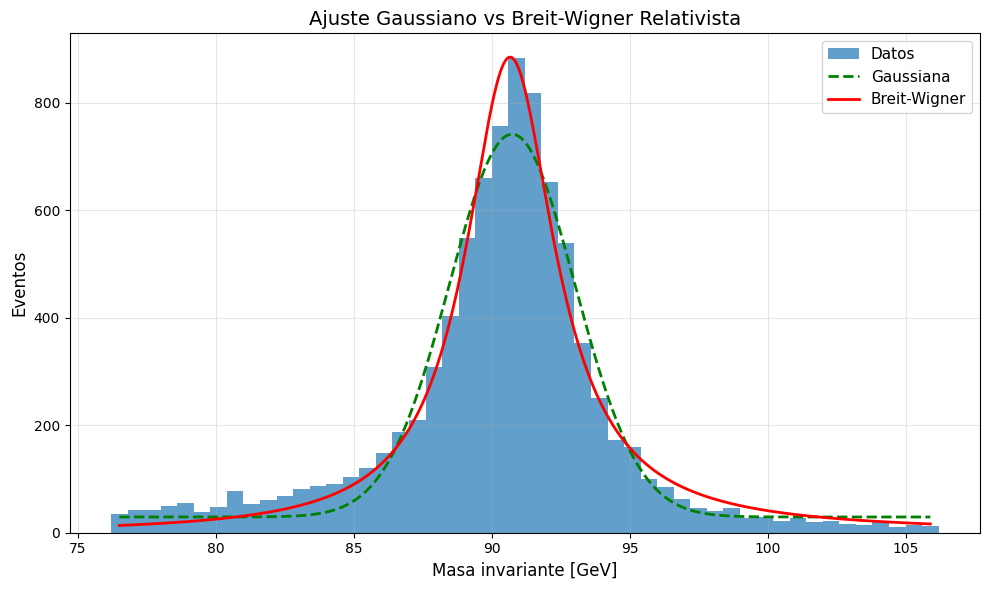

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

particles = pd.read_csv('https://opendata.cern.ch/record/5208/files/Zmumu.csv', delimiter=',')

# Masa invariante (fórmula de la diapositiva 11)
p1, p2 = particles['pt1'], particles['pt2']
eta1, eta2 = particles['eta1'], particles['eta2']
phi1, phi2 = particles['phi1'], particles['phi2']

M2 = 2 * p1 * p2 * (np.cosh(eta1 - eta2) - np.cos(phi1 - phi2))
mass = np.sqrt(np.maximum(M2, 0))
mass_clean = mass

# Región del pico (80-105 GeV)
mass_z = 91.2
window = 15
mass_peak = mass_clean[(mass_clean > mass_z - window) & (mass_clean < mass_z + window)]

# Histograma
hist, bin_edges = np.histogram(mass_peak, bins=50, range=(mass_z - window, mass_z + window))
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2


def gaussian(x, mean, sigma, amplitude, background):
    """Función gaussiana"""
    return amplitude * np.exp(-0.5 * ((x - mean) / sigma)**2) + background

def breit_wigner_relativista(x, mass, width, amplitude, background):
    """Breit-Wigner relativista"""
    x = np.maximum(x, 0.1)
    return amplitude * (x**2 * width**2) / ((x**2 - mass**2)**2 + x**2 * width**2) + background

print("="*60)
print("AJUSTE GAUSSIANO")
print("="*60)

# Ajuste gaussiano
p0_gauss = [mass_z, 2.0, max(hist), np.min(hist)]
popt_gauss, pcov_gauss = curve_fit(gaussian, bin_centers, hist, p0=p0_gauss,
                                   sigma=np.sqrt(np.maximum(hist, 1)))

mean_fit, sigma_fit, amp_fit, bg_fit = popt_gauss
perr_gauss = np.sqrt(np.diag(pcov_gauss))

print(f"Media: {mean_fit:.3f} ± {perr_gauss[0]:.3f} GeV")
print(f"Sigma (resolución): {sigma_fit:.3f} ± {perr_gauss[1]:.3f} GeV")
print(f"Amplitud: {amp_fit:.1f} ± {perr_gauss[2]:.1f}")
print(f"Fondo: {bg_fit:.1f} ± {perr_gauss[3]:.1f}")
print(f"FWHM: {2.3548*sigma_fit:.3f} GeV")

print("\n" + "="*60)
print("AJUSTE BREIT-WIGNER RELATIVISTA")
print("="*60)

# Ajuste Breit-Wigner relativista
p0_bw = [mass_z, 2.5, max(hist), np.min(hist)]
popt_bw, pcov_bw = curve_fit(breit_wigner_relativista, bin_centers, hist, p0=p0_bw,
                             sigma=np.sqrt(np.maximum(hist, 1)))

mass_fit, width_fit, amp_fit, bg_fit = popt_bw
perr_bw = np.sqrt(np.diag(pcov_bw))

print(f"Masa: {mass_fit:.3f} ± {perr_bw[0]:.3f} GeV")
print(f"Anchura (Γ): {width_fit:.3f} ± {perr_bw[1]:.3f} GeV")
print(f"Amplitud: {amp_fit:.1f} ± {perr_bw[2]:.1f}")
print(f"Fondo: {bg_fit:.1f} ± {perr_bw[3]:.1f}")
print(f"Vida media (τ = ħ/Γ): {6.582e-25/width_fit:.2e} s")

plt.figure(figsize=(10, 6))

plt.hist(mass_peak, bins=50, range=(mass_z - window, mass_z + window),
         alpha=0.7, label='Datos', linewidth=0.5)

x_fit = np.linspace(bin_centers[0], bin_centers[-1], 1000)
plt.plot(x_fit, gaussian(x_fit, *popt_gauss), 'g--', linewidth=2,
         label=f'Gaussiana')
plt.plot(x_fit, breit_wigner_relativista(x_fit, *popt_bw), 'r-', linewidth=2,
         label=f'Breit-Wigner')

plt.xlabel('Masa invariante [GeV]', fontsize=12)
plt.ylabel('Eventos', fontsize=12)
plt.title('Ajuste Gaussiano vs Breit-Wigner Relativista', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()